In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [59]:
import pandas as pd
import numpy as np
from moduli.preprocessing import (
    build_koppen_features,
    prepare_model_data,
)
from moduli.cluster_centroid_manipulation import compute_centroids
from moduli.fitness_functions import fitness_weighted_sum
from moduli.vegetation_eval import (
    load_clc_legend,
    evaluate_label_set
)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
df = pd.read_csv("../../df_valid.csv", index_col=0)
koppen = pd.read_csv("../../koppen_df_valid.csv", index_col=0)

df = df.merge(
    koppen[["row", "col", "koppen_class"]],
    on=["row", "col"],
    how="inner",
)

df = df.dropna(subset=["koppen_class"]).copy()

In [4]:
MODE = "superpixels"
FEATURE_MODE = "koppen"

N_CLUSTERS = 5
TARGET_SIZE = 150
K_NEIGHBORS = 16
RANDOM_STATE = 0

In [5]:
X_features, feature_names = build_koppen_features(df)
data = prepare_model_data(
    df=df,
    X_features=X_features,
    feature_names=feature_names,
    mode=MODE,
    target_size=TARGET_SIZE,
    k_neighbors=K_NEIGHBORS,
    scale_final=True,
    random_state=RANDOM_STATE,
)

X = data["X_model"]
neighbors = data["neighbors"]
weights = data["weights"]

df_model = data["df"]
node_col = data["node_col"]

In [6]:
node_koppen = (
    df_model
    .dropna(subset=["koppen_class"])
    .groupby(node_col)["koppen_class"]
    .agg(lambda x: x.value_counts().idxmax())
)

# Convert original Köppen codes to consecutive labels
codes = sorted(node_koppen.unique())
code_to_label = {code: i for i, code in enumerate(codes)}

koppen_node_labels = (
    node_koppen
    .sort_index()
    .map(code_to_label)
    .to_numpy(dtype=int)
)

print("Köppen classes:", code_to_label)
print("Number of nodes:", len(koppen_node_labels))
print("Expected nodes:", len(data["X_model"]))

Köppen classes: {8.0: 0, 14.0: 1, 15.0: 2, 26.0: 3, 27.0: 4}
Number of nodes: 2009
Expected nodes: 2009


In [11]:
centroids = compute_centroids(
    X=X,
    labels=koppen_node_labels,
    n_clusters=len(koppen_node_labels),
    weights=weights,
    rng=np.random.default_rng(0),
)

In [12]:
fit, terms = fitness_weighted_sum(
    X=X,
    labels=koppen_node_labels,
    centroids=centroids,
    weights=weights,
    neighbors=neighbors,
)
fit

0.3679283278942535

In [13]:
vegetation_path = "../../vegetacija.csv"
legend_path = "../../Vegetacija/u2018_clc2018_v2020_20u1_raster100m/Legend/CLC2018_CLC2018_V2018_20_QGIS.txt"
vegetation = pd.read_csv(vegetation_path)
legend = load_clc_legend(legend_path)

res_veg = evaluate_label_set(
    "koppen",
    koppen_node_labels,
    data["df"],
    data["node_col"],
    vegetation,
    legend,
)

In [14]:
res_veg[0]

{'mean_combined_ecological_consistency': 0.42985876879430274,
 'weighted_combined_ecological_consistency': 0.4425562125390131,
 'mean_agriculture_homogeneity': 0.4165000388332629,
 'weighted_agriculture_homogeneity': 0.40649361048681265,
 'mean_natural_homogeneity': 0.4799671821265787,
 'weighted_natural_homogeneity': 0.4937278400259055,
 'mean_artificial_share_total': 0.027312365436892673,
 'weighted_artificial_share_total': 0.03797988011453734,
 'method': 'koppen'}

In [ ]:
res = res_veg[0]
res["fitness"] = fit
res["compactness"] = terms["compactness"]
res["spatial"] = terms["spatial"]

koppen_res = pd.DataFrame(res, index=[0])
koppen_res.to_csv("koppen_res.csv")

In [17]:
data.keys()

dict_keys(['mode', 'df', 'feature_names', 'X_model_unscaled', 'X_model', 'coords_model', 'weights', 'neighbors', 'neighbor_dists', 'node_col', 'scaler', 'superpixel_model', 'superpixel_labels'])

In [20]:
koppen_labels_aggregated = pd.DataFrame(koppen_node_labels)
koppen_labels_aggregated.to_csv("../../koppen_labels_aggregated.csv")

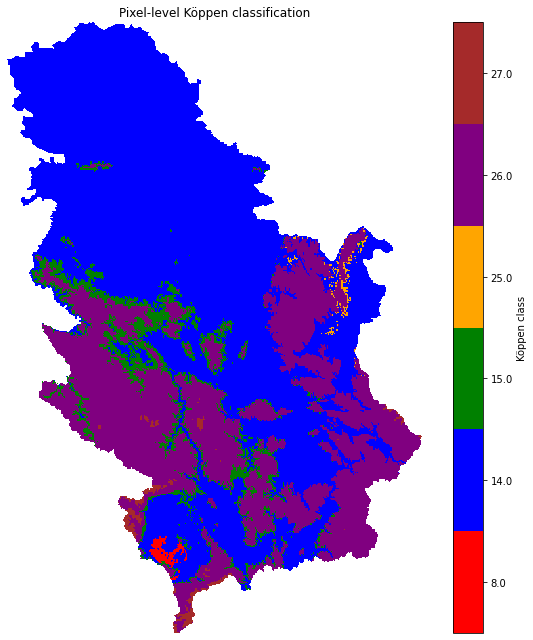

In [72]:
koppen_pixel = df
codes = sorted(koppen_pixel["koppen_class"].unique())
code_to_id = {code: i for i, code in enumerate(codes)}
id_to_code = {i: code for code, i in code_to_id.items()}

koppen_pixel["plot_id"] = koppen_pixel["koppen_class"].map(code_to_id)

n_rows = int(koppen_pixel["row"].max()) + 1
n_cols = int(koppen_pixel["col"].max()) + 1

grid = np.full((n_rows, n_cols), np.nan)

grid[
    koppen_pixel["row"].to_numpy(dtype=int),
    koppen_pixel["col"].to_numpy(dtype=int),
] = koppen_pixel["plot_id"].to_numpy(dtype=float)

colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "gray", "olive", "cyan"]
cmap = ListedColormap(colors[:len(codes)])
cmap.set_bad(color="white")

norm = BoundaryNorm(np.arange(-0.5, len(codes) + 0.5, 1), cmap.N)

fig = plt.figure(figsize=(9, 9))
img = plt.imshow(
    grid,
    cmap=cmap,
    norm=norm,
    origin="upper",
    interpolation="nearest",
)

cbar = plt.colorbar(img, ticks=np.arange(len(codes)))
cbar.ax.set_yticklabels([str(id_to_code[i]) for i in range(len(codes))])
cbar.set_label("Köppen class")

plt.title("Pixel-level Köppen classification")
plt.axis("off")
plt.tight_layout()
plt.show()
fig.savefig("../../plot_full_koppen.png", dpi=300, bbox_inches="tight")

In [61]:
df["koppen_class"].unique()

array([14., 15., 26., 25., 27.,  8.])

In [64]:
node_koppen.unique()

array([14., 26.,  8., 15., 27.])

In [67]:
slice8 = df[df["koppen_class"] == 8]
print(slice8["row"].min(), slice8["row"].max())
print(slice8["col"].min(), slice8["col"].max())

759 826
210 265


In [68]:
slice8.shape

(1109, 37)